# CG projector ranks for the updated plate system

This focused copy of the non-simplified v3 notebook retains only the data preparation, fixed-iteration CG directions, numerical-rank calculation, and requested plots for **box 1** and **box 2**. No other boxes are loaded or analyzed. The numerical-rank tolerance and A-normalization match v3. The rank-revealing QR uses a deterministic, overdetermined 4,400-row sketch containing all 2,200 direction columns; this preserves the column dependencies while keeping the factorization within memory.

Because $n=21{,}570$, explicitly constructing $Q_m$ or $\Pi_m$ for all 2,200 iterations would create dense multi-gigabyte arrays. Their ranks are therefore evaluated from the exact projector identities

$$
Q_m=P_mG_m^{-1}P_m^T\widehat A,\qquad
\operatorname{rank}(Q_m)=\operatorname{rank}(P_m),\qquad
\operatorname{rank}(\Pi_m)=n-\operatorname{rank}(Q_m),
$$

on the numerically independent column space.

In [1]:
from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import get_lapack_funcs
from scipy.sparse import diags, load_npz

data_dir = Path("system_updated_plate")
A = load_npz(data_dir / "A.npz").tocsr()
b = np.loadtxt(data_dir / "b.dat", dtype=float)
boxes = {
    "box 1": np.loadtxt(data_dir / "box_1.dat", dtype=float),
    "box 2": np.loadtxt(data_dir / "box_2.dat", dtype=float),
}

n = b.size
if A.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A.shape}.")
for box_name, box in boxes.items():
    if box.shape != (n, 2):
        raise ValueError(f"{box_name} should have shape {(n, 2)}, got {box.shape}.")

diagonal = A.diagonal()
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = diags(inverse_scale) @ A @ diags(inverse_scale)
b_hat = inverse_scale * b

max_cg_iterations = 2200
rank_tolerance = 1e-10
print(f"system dimension n: {n}")
print(f"maximum CG iteration count: {max_cg_iterations}")
print("analyzed boxes:", ", ".join(boxes))

system dimension n: 21570
maximum CG iteration count: 2200
analyzed boxes: box 1, box 2


In [2]:
def fixed_cg_directions(A, b, x0, iterations):
    """Run exactly `iterations` CG steps and retain A-normalized p_k."""
    x = np.array(x0, dtype=float, copy=True)
    residual = b - A @ x
    direction = residual.copy()
    # Fortran order lets LAPACK factor this array in place without a large copy.
    directions = np.empty((b.size, iterations), dtype=float, order="F")

    for k in range(iterations):
        applied_direction = A @ direction
        residual_norm_sq = float(residual @ residual)
        denominator = float(direction @ applied_direction)
        if denominator <= 0.0 or not np.isfinite(denominator):
            raise RuntimeError(f"CG breakdown at iteration {k + 1}.")

        a_norm_sq = float(direction @ applied_direction)
        if a_norm_sq <= 0.0 or not np.isfinite(a_norm_sq):
            raise RuntimeError(f"Invalid A-norm at iteration {k + 1}.")
        directions[:, k] = direction / np.sqrt(a_norm_sq)
        alpha = residual_norm_sq / denominator
        x += alpha * direction
        next_residual = residual - alpha * applied_direction
        if k + 1 < iterations:
            beta = float(next_residual @ next_residual) / residual_norm_sq
            direction = next_residual + beta * direction
        residual = next_residual

    return directions


def prefix_rank_profile(normalized_directions, tolerance=1e-10):
    """Return a rank-revealing profile for every leading CG prefix P_m.

    CG directions are first A-normalized, as in the v3 projection selector.
    One pivoted QR of the full trajectory determines the independent numerical
    column basis. Counting those basis columns by original CG index gives the
    numerical rank profile at every m without repeatedly factoring P[:, :m].
    """
    # geqp3 computes pivoted QR without explicitly forming the large Q factor.
    normalized_f = np.asfortranarray(normalized_directions)
    geqp3 = get_lapack_funcs("geqp3", (normalized_f,))
    factored, pivots, tau, work, info = geqp3(
        normalized_f, overwrite_a=True
    )
    if info != 0:
        raise RuntimeError(f"LAPACK geqp3 failed with info={info}.")

    diagonal = np.abs(np.diag(factored[: min(factored.shape), :]))
    if diagonal.size == 0 or diagonal[0] == 0.0:
        numerical_rank = 0
        independent_indices = np.array([], dtype=int)
    else:
        numerical_rank = int(np.sum(diagonal > tolerance * diagonal[0]))
        independent_indices = np.asarray(pivots[:numerical_rank] - 1, dtype=int)

    increments = np.bincount(
        independent_indices, minlength=normalized_directions.shape[1]
    )
    rank_P = np.r_[0, np.cumsum(increments, dtype=int)]
    return rank_P, numerical_rank


def projector_rank_histories(rank_P, n):
    """Use Q=P G^-1 P^T A and Pi=I-Q rank identities.

    On the numerical independent column space, G is nonsingular, A is SPD,
    rank(Q_m)=rank(P_m), and rank(Pi_m)=n-rank(Q_m).
    """
    rank_Q = rank_P.copy()
    rank_Pi = n - rank_Q
    return rank_Q, rank_Pi


def plot_rank_history(ax, iterations, rank_P, rank_Q, rank_Pi, n, title):
    expected_P = iterations
    expected_Pi = n - rank_Q
    marker_stride = max(1, len(iterations) // 28)

    # P_m and Q_m use the left axis.
    ax.plot(
        iterations, expected_P, color="0.55", linestyle="--", linewidth=1.8,
        label=r"Expected rank$(P_m)=m$", zorder=1,
    )
    ax.plot(
        iterations, rank_Q, color="tab:orange", linestyle="-.", linewidth=1.7,
        marker="x", markevery=marker_stride, markersize=4,
        label=r"Actual rank$(Q_m)$", zorder=2,
    )
    ax.plot(
        iterations, rank_P, color="tab:blue", linewidth=1.4,
        marker="o", markevery=marker_stride, markersize=3, fillstyle="none",
        label=r"Actual rank$(P_m)$", zorder=3,
    )
    ax.set_xlabel("CG iteration $m$")
    ax.set_ylabel(r"rank$(P_m)$ and rank$(Q_m)$")
    ax.grid(alpha=0.25)

    # Pi_m is on a second scale, which is essential for the 21,570-D system.
    pi_ax = ax.twinx()
    pi_ax.plot(
        iterations, expected_Pi, color="0.35", linestyle=":", linewidth=2.2,
        label=r"Expected rank$(\Pi_m)=n-$rank$(Q_m)$", zorder=1,
    )
    pi_ax.plot(
        iterations, rank_Pi, color="tab:green", linewidth=1.5,
        marker="s", markevery=marker_stride, markersize=3, fillstyle="none",
        label=r"Actual rank$(\Pi_m)$", zorder=2,
    )
    pi_ax.set_ylabel(r"rank$(\Pi_m)$")

    lines = ax.get_lines() + pi_ax.get_lines()
    ax.legend(lines, [line.get_label() for line in lines], loc="best", fontsize=8)
    ax.set_title(title)
    return pi_ax


In [3]:
rank_results = {}
rng = np.random.default_rng(0)
rank_rows = np.sort(rng.choice(n, size=4400, replace=False))

for box_name, box in boxes.items():
    x0 = scale * np.mean(box, axis=1)
    directions = fixed_cg_directions(
        A_hat, b_hat, x0, max_cg_iterations
    )
    direction_sketch = np.asfortranarray(directions[rank_rows, :])
    del directions
    gc.collect()

    rank_P, final_rank = prefix_rank_profile(
        direction_sketch, tolerance=rank_tolerance
    )
    rank_Q, rank_Pi = projector_rank_histories(rank_P, n)
    result = {
        "rank_P": rank_P,
        "rank_Q": rank_Q,
        "rank_Pi": rank_Pi,
    }
    rank_results[box_name] = result
    print(
        f"{box_name}: final rank(P_m)={final_rank}, "
        f"rank(Q_m)={rank_Q[-1]}, rank(Pi_m)={rank_Pi[-1]}"
    )
    del direction_sketch
    gc.collect()

box 1: final rank(P_m)=1939, rank(Q_m)=1939, rank(Pi_m)=19631


box 2: final rank(P_m)=1939, rank(Q_m)=1939, rank(Pi_m)=19631


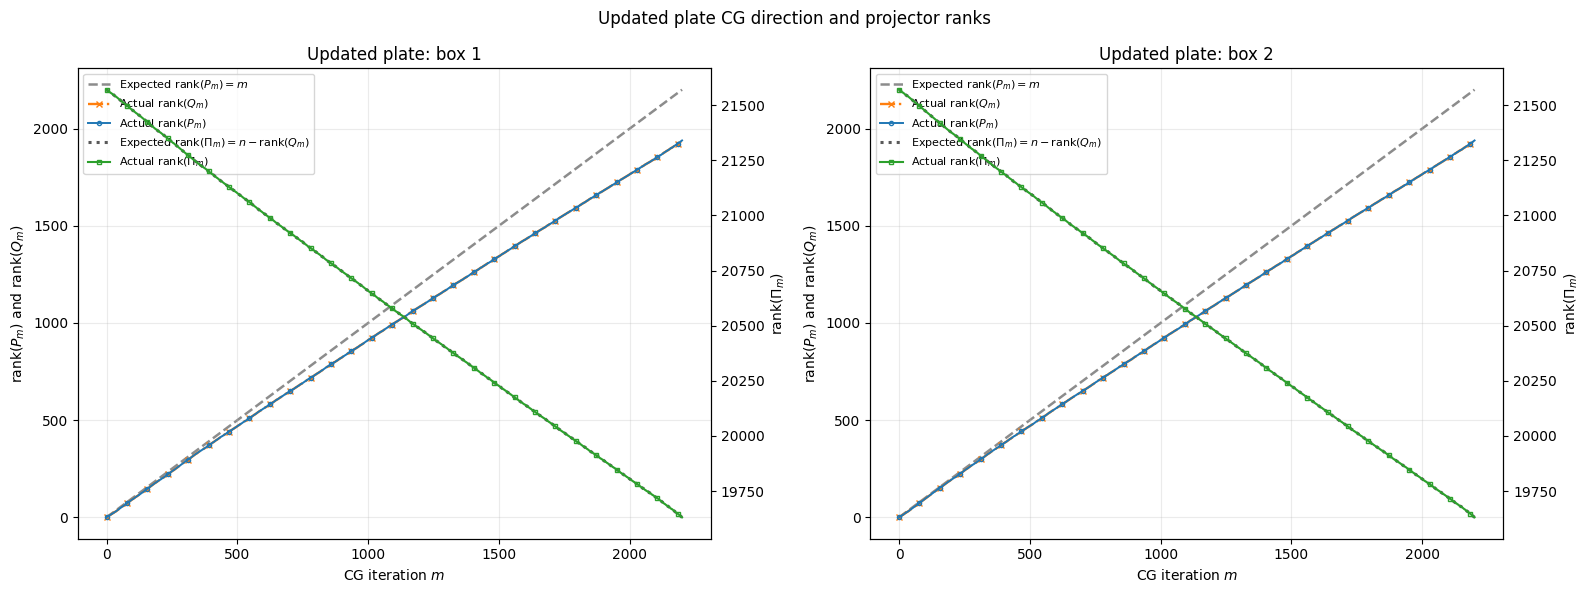

In [4]:
iterations = np.arange(max_cg_iterations + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for ax, (box_name, result) in zip(axes, rank_results.items()):
    plot_rank_history(
        ax,
        iterations,
        result["rank_P"],
        result["rank_Q"],
        result["rank_Pi"],
        n,
        f"Updated plate: {box_name}",
    )

fig.suptitle("Updated plate CG direction and projector ranks")
fig.tight_layout()
plt.show()